In [51]:
import xarray as xr
import datetime as dt
import glob
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd

In [107]:
def plot_var(ax, name, time, lat, lon, var, levs, cmap_str, units = "", cbar=False, cax=None, cbar_lab=""):
    f = xr.open_dataset(glob.glob("/g/data/eg3/ab4502/ExtremeWind/aus/era5/era5_"\
                        +time.strftime("%Y%m")+"*.nc")[0])
    
    data = f.sel({"time":time.replace(minute=0)})[var]
    c = xr.plot.contourf(data, levels=levs, ax=ax, cmap=plt.get_cmap(cmap_str),
                    add_labels=False, add_colorbar=False)   
    ax.plot(lon, lat, color="k", marker="x", mew=3, ms=12)    
    ax.coastlines()    
    if cbar:
        cbar_obj = plt.colorbar(c, cax=cax, orientation="vertical")
        cbar_obj.set_label(cbar_lab)
    ax.set_xlim([lon-4, lon+4])
    ax.set_ylim([lat-4, lat+4])    
    ax.set_title(dt.datetime.strftime(pd.to_datetime(data.time.values),"%Y-%m-%d %H:%M") + 
              ": "+str(np.round(data.interp({"lat":lat, "lon":lon}, method="nearest").values,1)) + " "+units)
    
def extract_var(time, lat, lon, var):
    f = xr.open_dataset(glob.glob("/g/data/eg3/ab4502/ExtremeWind/aus/era5/era5_"\
                        +time.strftime("%Y%m")+"*.nc")[0])
    
    data = f.sel({"time":time.replace(minute=0)})[var]

    return np.round(data.interp({"lat":lat, "lon":lon}, method="nearest").values,1)




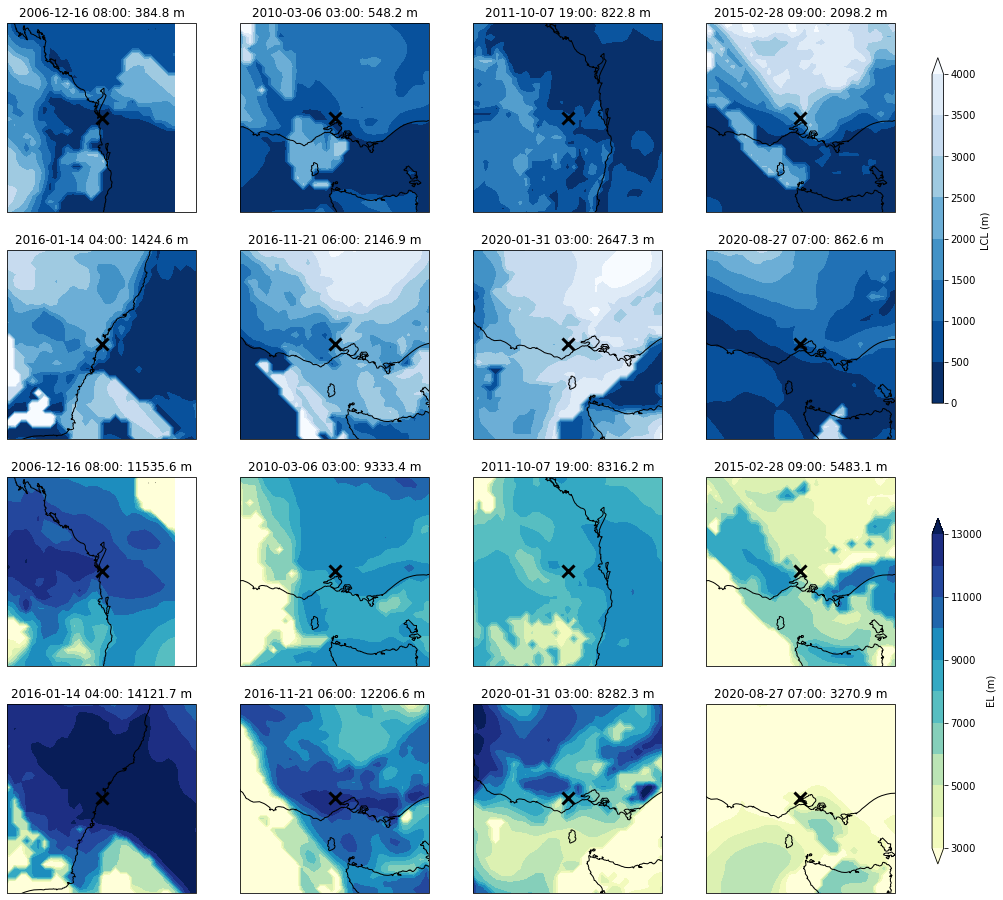

In [106]:
plt.figure(figsize=[16,16])
levs = np.arange(0,4500,500)
cmap_str = "Blues_r"
units="m"

name="DOUBLE ISLAND POINT"; lat=-25.9319; lon=153.1906; time = dt.datetime(2006,12,16,8,1)
ax1 = plt.subplot(441,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,"mu_lcl",levs,cmap_str,units=units)

name="MELBOURNE WARM 3"; lat=-37.6654; lon=144.8322; time = dt.datetime(2010,3,6,3,24)
ax1 = plt.subplot(442,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,"mu_lcl",levs,cmap_str,units=units)

name="OAKEY"; lat=-27.4034; lon=151.7413; time = dt.datetime(2011,10,7,19,21)
ax1 = plt.subplot(443,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,"mu_lcl",levs,cmap_str,units=units)

name="MELBOURNE WARM1"; lon = 144.8322; lat = -37.6654; time = dt.datetime(2015,2,28,9,24)
ax1 = plt.subplot(444,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,"mu_lcl",levs,cmap_str,units=units)

name="SYDNEY"; lat=-33.9465; lon=151.1731; time = dt.datetime(2016,1,14,4,19)
ax1 = plt.subplot(4,4,5,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,"mu_lcl",levs,cmap_str,units=units)

name="MELBOURNE WARM2"; lat=-37.9075; lon=144.1303; time = dt.datetime(2016,11,21,6,1)
ax1 = plt.subplot(4,4,6,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,"mu_lcl",levs,cmap_str,units=units)

name="CRESSY"; lat = -38.2332; lon = 143.7924; time = dt.datetime(2020,1,31,3,42)
ax1 = plt.subplot(4,4,7,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,"mu_lcl",levs,cmap_str,units=units)

name="MELBOURNE COOL1"; lon = 144.4783; lat = -38.0288; time = dt.datetime(2020,8,27,7,12)
ax1 = plt.subplot(4,4,8,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,"mu_lcl",levs,cmap_str,cbar=True,cax = plt.axes([0.93,0.55,0.01,0.3]),
         cbar_lab="LCL (m)",units=units)




levs = np.arange(3000,14000,1000)
cmap_str = "YlGnBu"

name="DOUBLE ISLAND POINT"; lat=-25.9319; lon=153.1906; time = dt.datetime(2006,12,16,8,1)
ax1 = plt.subplot(449,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,"mu_el",levs,cmap_str,units=units)

name="MELBOURNE WARM 3"; lat=-37.6654; lon=144.8322; time = dt.datetime(2010,3,6,3,24)
ax1 = plt.subplot(4,4,10,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,"mu_el",levs,cmap_str,units=units)

name="OAKEY"; lat=-27.4034; lon=151.7413; time = dt.datetime(2011,10,7,19,21)
ax1 = plt.subplot(4,4,11,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,"mu_el",levs,cmap_str,units=units)

name="MELBOURNE WARM1"; lon = 144.8322; lat = -37.6654; time = dt.datetime(2015,2,28,9,24)
ax1 = plt.subplot(4,4,12,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,"mu_el",levs,cmap_str,units=units)

name="SYDNEY"; lat=-33.9465; lon=151.1731; time = dt.datetime(2016,1,14,4,19)
ax1 = plt.subplot(4,4,13,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,"mu_el",levs,cmap_str,units=units)

name="MELBOURNE WARM2"; lat=-37.9075; lon=144.1303; time = dt.datetime(2016,11,21,6,1)
ax1 = plt.subplot(4,4,14,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,"mu_el",levs,cmap_str,units=units)

name="CRESSY"; lat = -38.2332; lon = 143.7924; time = dt.datetime(2020,1,31,3,42)
ax1 = plt.subplot(4,4,15,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,"mu_el",levs,cmap_str,units=units)

name="MELBOURNE COOL1"; lon = 144.4783; lat = -38.0288; time = dt.datetime(2020,8,27,7,12)
ax1 = plt.subplot(4,4,16,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,"mu_el",levs,cmap_str,cbar=True,cax = plt.axes([0.93,0.15,0.01,0.3]),
         cbar_lab="EL (m)",units=units)

plt.savefig("/g/data/eg3/ab4502/figs/ExtremeWind/case_studies/ml_lcl_scws.jpeg", pil_kwargs={'quality': 100}, bbox_inches="tight")

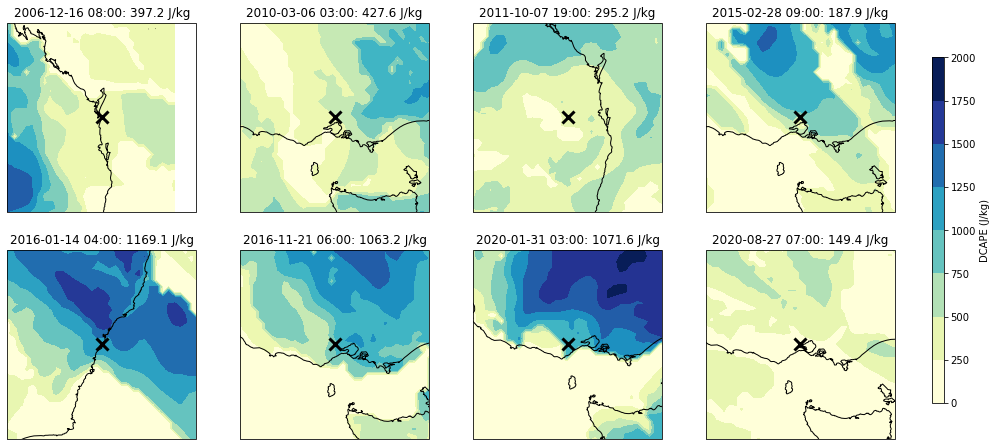

In [104]:
plt.figure(figsize=[16,16])
levs = np.arange(0,2250,250)
cmap_str = "YlGnBu"
v="dcape"
row=4; col=4
units="J/kg"

name="DOUBLE ISLAND POINT"; lat=-25.9319; lon=153.1906; time = dt.datetime(2006,12,16,8,1)
ax1 = plt.subplot(row,col,1,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,v,levs,cmap_str,units=units)

name="MELBOURNE WARM 3"; lat=-37.6654; lon=144.8322; time = dt.datetime(2010,3,6,3,24)
ax1 = plt.subplot(row, col,2 ,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,v,levs,cmap_str,units=units)

name="OAKEY"; lat=-27.4034; lon=151.7413; time = dt.datetime(2011,10,7,19,21)
ax1 = plt.subplot(row, col,3 ,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,v,levs,cmap_str,units=units)

name="MELBOURNE WARM1"; lon = 144.8322; lat = -37.6654; time = dt.datetime(2015,2,28,9,24)
ax1 = plt.subplot(row, col,4 ,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,v,levs,cmap_str,units=units)

name="SYDNEY"; lat=-33.9465; lon=151.1731; time = dt.datetime(2016,1,14,4,19)
ax1 = plt.subplot(row, col,5 ,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,v,levs,cmap_str,units=units)

name="MELBOURNE WARM2"; lat=-37.9075; lon=144.1303; time = dt.datetime(2016,11,21,6,1)
ax1 = plt.subplot(row, col,6 ,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,v,levs,cmap_str,units=units)

name="CRESSY"; lat = -38.2332; lon = 143.7924; time = dt.datetime(2020,1,31,3,42)
ax1 = plt.subplot(row, col,7 ,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,v,levs,cmap_str,units=units)

name="MELBOURNE COOL1"; lon = 144.4783; lat = -38.0288; time = dt.datetime(2020,8,27,7,12)
ax1 = plt.subplot(row, col,8 ,projection=ccrs.PlateCarree())
plot_var(ax1, name,time,lat,lon,v,levs,cmap_str,cbar=True,cax = plt.axes([0.93,0.55,0.01,0.3]),
         cbar_lab="DCAPE (J/kg)",units=units)

plt.savefig("/g/data/eg3/ab4502/figs/ExtremeWind/case_studies/dcape_scws.jpeg", pil_kwargs={'quality': 100}, bbox_inches="tight")

In [111]:
lcl = []
dcape = []
el = []

lat=-25.9319; lon=153.1906; time = dt.datetime(2006,12,16,8,1)
lcl.append(extract_var(time,lat,lon,"mu_lcl"))
dcape.append(extract_var(time,lat,lon,"dcape"))
el.append(extract_var(time,lat,lon,"mu_el"))

lat=-37.6654; lon=144.8322; time = dt.datetime(2010,3,6,3,24)
lcl.append(extract_var(time,lat,lon,"mu_lcl"))
dcape.append(extract_var(time,lat,lon,"dcape"))
el.append(extract_var(time,lat,lon,"mu_el"))

lat=-27.4034; lon=151.7413; time = dt.datetime(2011,10,7,19,21)
lcl.append(extract_var(time,lat,lon,"mu_lcl"))
dcape.append(extract_var(time,lat,lon,"dcape"))
el.append(extract_var(time,lat,lon,"mu_el"))

lon = 144.8322; lat = -37.6654; time = dt.datetime(2015,2,28,9,24)
lcl.append(extract_var(time,lat,lon,"mu_lcl"))
dcape.append(extract_var(time,lat,lon,"dcape"))
el.append(extract_var(time,lat,lon,"mu_el"))

lat=-33.9465; lon=151.1731; time = dt.datetime(2016,1,14,4,19)
lcl.append(extract_var(time,lat,lon,"mu_lcl"))
dcape.append(extract_var(time,lat,lon,"dcape"))
el.append(extract_var(time,lat,lon,"mu_el"))

lat=-37.9075; lon=144.1303; time = dt.datetime(2016,11,21,6,1)
lcl.append(extract_var(time,lat,lon,"mu_lcl"))
dcape.append(extract_var(time,lat,lon,"dcape"))
el.append(extract_var(time,lat,lon,"mu_el"))

lat = -38.2332; lon = 143.7924; time = dt.datetime(2020,1,31,3,42)
lcl.append(extract_var(time,lat,lon,"mu_lcl"))
dcape.append(extract_var(time,lat,lon,"dcape"))
el.append(extract_var(time,lat,lon,"mu_el"))

lon = 144.4783; lat = -38.0288; time = dt.datetime(2020,8,27,7,12)
lcl.append(extract_var(time,lat,lon,"mu_lcl"))
dcape.append(extract_var(time,lat,lon,"dcape"))
el.append(extract_var(time,lat,lon,"mu_el"))


Text(0, 0.5, 'DCAPE')

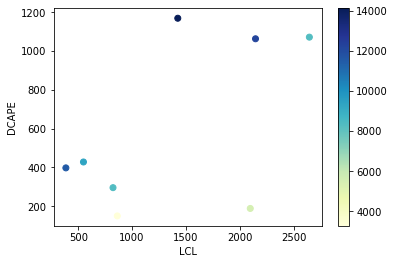

In [122]:
plt.scatter(lcl,dcape,c=el,cmap=plt.get_cmap("YlGnBu")); plt.colorbar()
plt.xlabel("LCL"); plt.ylabel("DCAPE")